In [1]:
import spatialdata as sd
import spatialdata_plot
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io
import pandas as pd
import sopa
from skimage import io as skio
from skimage.measure import regionprops_table #library for calculate centroids
from spatialdata.models import Labels2DModel, ShapesModel
import rasterio.features
import shapely.geometry
import geopandas as gpd
import anndata as ad
from shapely.geometry import shape

/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" #in order to exclude GPU accelaration which cause conflitcts
import spatialdata as sd
from skimage import io as skio
import numpy as np
import pandas as pd
import rasterio.features
import geopandas as gpd
import shapely.geometry
from shapely.geometry import shape
from spatialdata.models import Labels2DModel, ShapesModel
import sopa
import anndata as ad

/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#Import data
#work with a copy since modification on spatial data object are in place write on disk
data_path = "/home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_c26foxO_(Copy)"
sdata = sd.read_zarr(data_path)


no parent found for <ome_zarr.reader.Label object at 0x76abc03d1850>: None


In [3]:
sdata

SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_c26foxO_(Copy)
├── Images
│     ├── 'blocco1_fluo_image': DataTree[cyx] (1, 7718, 16166), (1, 3859, 8083), (1, 1929, 4041), (1, 964, 2020)
│     ├── 'blocco1_full_image': DataTree[cyx] (3, 7718, 16166), (3, 3859, 8083), (3, 1929, 4041), (3, 964, 2020), (3, 482, 1010)
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 2038, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 204, 427)
│     └── 'raster_arivis_nuclei': DataArray[cyx] (1, 5585, 11354)
├── Labels
│     └── 'label_nuclei_arivis': DataArray[yx] (7728, 16176)
├── Shapes
│     ├── 'blocco1_square_002um': GeoDataFrame shape: (837234, 1) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (53219, 1) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (13575, 1) (2D shapes)
│     ├── 'fibers_polygons': GeoDataFrame shape: (4284, 2) (2D shapes)
│     ├── 'intissue_GFP_poly_c26foxO': GeoDat

In [23]:
#read and upload mask obtained through cellpose
cellpose_mask= skio.imread("/home/stefano/Documents/Spatial-Transcriptomic/images/blocco1/masks/blocco1_c26foxO_masks.tif")

In [16]:
print(f"the number of segmented fibers are: {len(np.unique(cellpose_mask))}")

the number of segmented fibers are: 4364


In [17]:
#obtain the transformation to apply to the mask from full res image
original_coords = sd.transformations.get_transformation(sdata.images['blocco1_full_image'], get_all= True)
original_coords

{'blocco1': Sequence 
     Translation (c, y, x)
         [    0. 15000.     0.]
     Identity }

In [24]:
#extract geometrical boundaries of the segmented fibers from the mask
shapes_generator = rasterio.features.shapes(cellpose_mask.astype(np.int32), mask=(cellpose_mask>0))
poligons = []
ids = []

for geom, value in shapes_generator:
    poligons.append(shape(geom))
    ids.append(int(value))

gdf = gpd.GeoDataFrame({'geometry': poligons, 'fiber_id':ids})


#Convert in a ShapedModel element in order to add to the Spatial Data object
#shapes_element = ShapesModel.parse(gdf, transformations=original_coords)
#sdata.shapes['fiber_polygons'] = shapes_element
#shapes_element

Here we have a problem: there are "x" segmented fibers but  rasterio.features.shapes defined "y" elements, if x!=y we need to merge element with the same label since some fibers have benn fragmented in more geometric pieces.

In [27]:
#SOLUTION OF THE PROBLEM: merge the geometry which have the same fiber label
gdf_cleaned = gdf.dissolve(by='fiber_id', as_index=True)
gdf_cleaned['fiber_id'] = gdf_cleaned.index #restore the column after dissolve

shapes_element = ShapesModel.parse(gdf_cleaned, transformations=original_coords) #parse coordinate of the polygons (boundary of fibers) respect to the coords of the full res image

sdata.shapes['fibers_polygons'] = shapes_element #add the information of the coordinates of the shape to the spatial data object


In [28]:
sdata.shapes['fibers_polygons']

,geometry,fiber_id
fiber_id,,
1,"POLYGON ((6512 416, 6512 420, 6488 420, 6488 4...",1
2,"POLYGON ((6308 424, 6308 428, 6292 428, 6292 4...",2
3,"POLYGON ((6424 424, 6424 428, 6400 428, 6400 4...",3
4,"POLYGON ((6600 424, 6600 428, 6588 428, 6588 4...",4
5,"POLYGON ((6672 424, 6672 428, 6656 428, 6656 4...",5
...,...,...
4359,"POLYGON ((11788 6296, 11788 6304, 11784 6304, ...",4359
4360,"POLYGON ((11556 6300, 11556 6304, 11552 6304, ...",4360
4361,"POLYGON ((11592 6304, 11592 6308, 11584 6308, ...",4361


In [29]:
sdata

SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_c26foxO_(Copy)
├── Images
│     ├── 'blocco1_fluo_image': DataTree[cyx] (1, 7718, 16166), (1, 3859, 8083), (1, 1929, 4041), (1, 964, 2020)
│     ├── 'blocco1_full_image': DataTree[cyx] (3, 7718, 16166), (3, 3859, 8083), (3, 1929, 4041), (3, 964, 2020), (3, 482, 1010)
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 2038, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 204, 427)
│     └── 'raster_arivis_nuclei': DataArray[cyx] (1, 5585, 11354)
├── Labels
│     └── 'label_nuclei_arivis': DataArray[yx] (7728, 16176)
├── Shapes
│     ├── 'blocco1_square_002um': GeoDataFrame shape: (837234, 1) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (53219, 1) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (13575, 1) (2D shapes)
│     ├── 'fibers_polygons': GeoDataFrame shape: (4363, 2) (2D shapes)
│     ├── 'intissue_GFP_poly_c26foxO': GeoDat

In [31]:
#aggregation with sopa
sopa.aggregate(sdata,key_added='segmented_fiber' ,bins_key='square_002um', shapes_key='fibers_polygons',expand_radius_ratio=0, min_transcripts=10,
            min_intensity_ratio=0.15, no_overlap=True)
#output produces error probably due the conflict in the index assignment of the fiber, in fact alphanumeric index is assigned instead of a number.
#anyway the aggregation occurs.

/home/stefano/miniconda3/envs/spatial/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
[INFO] (sopa.aggregation.aggregation) 79 cell(s) not passing filtering due to transcript count < 10
[INFO] (sopa.aggregation.channels) Aggregating channels intensity over 4363 cells with mode='average'


[########################################] | 100% Completed | 23.25 s


[INFO] (sopa.aggregation.aggregation) 0 cell(s) not passing filtering due to mean channel intensity < 30.91
/home/stefano/miniconda3/envs/spatial/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/home/stefano/miniconda3/envs/spatial/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/home/stefano/miniconda3/envs/spatial/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/home/stefano/miniconda3/envs/spatial/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/home/stefano/miniconda3/envs/spatial/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/home/s

In [36]:
#test if boundary conflict are resolved differently if we set no_overlap=False respect if it setted to True
test = sopa.aggregation.aggregate_bins(sdata, shapes_key='fibers_polygons', bins_key='square_002um', no_overlap=False)
test_1 = sopa.aggregation.aggregate_bins(sdata, shapes_key='fibers_polygons', bins_key='square_002um', no_overlap=True)

/home/stefano/miniconda3/envs/spatial/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/stefano/miniconda3/envs/spatial/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [37]:
count_matrix = test.X.toarray() if hasattr(test.X, 'toarray') else test.X
count_matrix_1 = test_1.X.toarray()

In [38]:
somma_strict = np.sum(count_matrix, axis=1)
somma_shared = np.sum(count_matrix_1, axis=1)

differences = somma_strict - somma_shared

differences_indices = np.where(differences!=0)

In [39]:
#no differencies found usinf no_overlap=False instead of no_overlap=True. Strange
differences_indices

(array([], dtype=int64),)

# RCTD
Create an AnnData object which contain:
* fiber expr matrix
* centroid matrix

In [6]:
#Obtain centroid matrix, with coordinate centroids of each fiber
polygon_centroids = sdata.shapes['fibers_polygons'].copy()
polygon_centroids['X'] = polygon_centroids.geometry.centroid.x
polygon_centroids['Y'] = polygon_centroids.centroid.y
polygon_centroids = polygon_centroids[['X','Y']] #hold only X and Y values
polygon_centroids.index = sdata.shapes['fibers_polygons']['fiber_id']

In [7]:
polygon_centroids

,X,Y
fiber_id,,
1,6524.352574,469.151326
2,6313.945865,485.663158
3,6416.027821,477.888717
4,6605.163636,476.303030
5,6686.894915,474.867797
...,...,...
4293,12913.247619,6031.057143
4294,12652.164706,6013.309804
4295,12857.577396,6046.324324


In [7]:
sdata.tables

{'arivis_nuclei_table': AnnData object with n_obs × n_vars = 5448 × 32285
    obs: 'region', 'slide', 'cell_id', 'area', 'GFP_value', 'eccentricity', 'solidity', 'extent', 'major_axis_length', 'minor_axis_length', 'in_treatment', 'to_discard', 'nuclei_types'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'sopa_attrs'
    obsm: 'bins_assignments', 'intensities', 'spatial', 'segmented_fiber_1': AnnData object with n_obs × n_vars = 4284 × 32285
    obs: 'region', 'slide', 'cell_id', 'area'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'sopa_attrs'
    obsm: 'spatial', 'bins_assignments', 'intensities', 'square_002um': AnnData object with n_obs × n_vars = 837234 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'in_treatment', 'to_discard', 'GFP_value'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial', 'square_008um': AnnData object with n_obs × n_vars =

In [8]:
#define genes names and organize them in a Pandas data frame
genes_names_string = [str(g) for g in sdata.tables['segmented_fiber_1'].var.index]
gene_name_df = pd.DataFrame(
    index = pd.Index(genes_names_string, dtype=object)
)

In [9]:
#Create an AnnData object which contain fiber expression matrix and coordinates of centroids 
adata_rctd = ad.AnnData(X=sdata.tables['segmented_fiber_1'].X, obs=polygon_centroids, var=gene_name_df)


/home/stefano/miniconda3/envs/spatial/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [51]:
adata_rctd

AnnData object with n_obs × n_vars = 4284 × 32285
    obs: 'X', 'Y'

In [212]:
sdata.tables['segmented_fiber']

AnnData object with n_obs × n_vars = 4284 × 32285
    obs: 'region', 'slide', 'cell_id', 'area'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'spatial', 'bins_assignments', 'intensities'

# Preparation of the reference data

In [10]:
from rctd import Reference, run_rctd, RCTDConfig
from scipy.io import mmread
import scanpy as sc

In [11]:
#build reference with data coming from single-cell experiments
# 1. Carica la matrice sparsa e i metadati
mat = mmread("/home/stefano/Documents/Spatial-Transcriptomic/annotation/reference/ref_counts.mtx").tocsr() # Legge la matrice dei conteggi
genes = pd.read_csv("/home/stefano/Documents/Spatial-Transcriptomic/annotation/reference/ref_genes.txt", header=None)[0].values
barcodes = pd.read_csv("/home/stefano/Documents/Spatial-Transcriptomic/annotation/reference/ref_barcodes.txt", header=None)[0].values
metadata = pd.read_csv("/home/stefano/Documents/Spatial-Transcriptomic/annotation/reference/ref_metadata.csv", index_col=0)


In [12]:
#reconstruct AnnDatata cells x genes, do the transpose to obtain that shapes
adata_ref = sc.AnnData(X=mat.T, obs=metadata)
adata_ref.obs_names = barcodes
adata_ref.var_names = genes

#check  the content
print(adata_ref)

AnnData object with n_obs × n_vars = 18563 × 32285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'dataset', 'cond

In [13]:
#create the reference
reference = Reference(adata_ref, cell_type_col='subclusters')
print(f"Reference profiles: {reference.profiles.shape}")
print(f"Cell types: {reference.cell_type_names}")

Reference profiles: (32285, 15)
Cell types: ['Endothelial', 'FAPs', 'Immune_Cells', 'MuSC', 'Myonuclei_IIb', 'Myonuclei_IIx', 'Myonuclei_IIx_IIa', 'Myonuclei_IIx_IIb', 'Myonuclei_MTJ', 'Myonuclei_NMJ', 'Myonuclei_Trim63', 'Nervous_System', 'Pericyte', 'Smooth_Muscular', 'Tenocyte']


# Run RCTD

In [14]:
#here change enviroment in order to avoid conflict, particularly regarding the use o 
from rctd import SPOT_CLASS_NAMES
import time
import rctd
import torch
import os

In [15]:
#see if we can use GPU acceleration for faster computation and avoid crash due to the low computational power of the cpu
print("is CUDA available?:", torch.cuda.is_available())
print("Name of the GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Nessuna GPU rilevata")

is CUDA available?: False
Name of the GPU: Nessuna GPU rilevata


In [16]:
#settings to avoid unwanted stoppages
#os.environ["TORCH_COMPILE_DISABLE"] = "1"
#os.environ["TORCHDYNAMO_DISABLE"] = "1"
#torch._dynamo.config.disable = True

#run rctd
_config = RCTDConfig(UMI_min=1, UMI_min_sigma=1)
_t0 = time.time()
result_multi = run_rctd(adata_rctd, reference, mode='multi', config=_config)
t_multi = time.time() - _t0
print(f'Multi mode: {t_multi:.1f}s')
print(f'Types per bead: min={result_multi.n_types.min()}, max={result_multi.n_types.max()}') #cell population heterogeneity, min=1 fiber population is explained only by a cellular type
                                                                                             #max=4 fiber population is explained by 4 cellular type

Gene lists: bulk=3211, reg=1994 (from 32245 common)
Fitting bulk platform effects...
Using 1994 DE genes for pixel-level fitting
Estimating sigma...


/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(


Chosen sigma: 0.29 (492.4s)
Auto batch size: 10000
Running in multi mode...


/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/home/stefano/miniconda3/envs/spatial/lib/python3.11/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(


Multi mode: 909.5s
Types per bead: min=1, max=4


In [17]:
#using the results of rctd create a dataframe with shape: fiber x cells_type, with elements corrsponding to the probability of a specific fiber to belonging to a cells type
cellular_type=reference.cell_type_names #define the possible cellular type 
fiber_id = adata_rctd.obs_names 

# create an array with row equal to fiber id and columns equal to genes
weights_df = pd.DataFrame(
    result_multi.weights, 
    index=fiber_id, 
    columns=cellular_type
)

# Ora puoi guardare le prime righe!
print(weights_df.head())

          Endothelial      FAPs  Immune_Cells      MuSC  Myonuclei_IIb  \
fiber_id                                                                 
1            0.000026  0.047423      0.011148  0.000026       0.205565   
2            0.000037  0.024047      0.169863  0.000037       0.257815   
3            0.000037  0.000037      0.075939  0.000037       0.132025   
4            0.025641  0.000053      0.000053  0.000053       0.048976   
5            0.000132  0.137017      0.087550  0.018158       0.059859   

          Myonuclei_IIx  Myonuclei_IIx_IIa  Myonuclei_IIx_IIb  Myonuclei_MTJ  \
fiber_id                                                                       
1              0.000026           0.000026           0.014793       0.000026   
2              0.000037           0.000037           0.003432       0.000037   
3              0.000037           0.000037           0.075918       0.000037   
4              0.000053           0.000053           0.000053       0.000053   
5

In [ ]:
#since rctd requires time to run, save the weight_df in local
#weights_df.to_parquet('/home/stefano/Documents/Spatial-Transcriptomic/annotation/rctd_results/rctd_weights_blocco1_c26foxO.parquet', index=True) # save
#for upload
weights_df = pd.read_parquet("/home/stefano/Documents/Spatial-Transcriptomic/annotation/rctd_results/rctd_weights_blocco1_c26foxO.parquet")
#weights_df_old = pd.read_parquet("/home/stefano/Documents/Spatial-Transcriptomic/annotation/rctd_results/rctd_weights_bins_centroids.parquet")


# Analysis of the results

The resulting dataframe of rctd method represent the estimated contribution of cellular type j in the spot(fiber) i. In other words: Considering the total nunmber of transcripts captured in that fiber, how much of this signal is captured by genes marker of the cellular type X?

In [20]:
dominant_cell_type = weights_df.idxmax(axis=1) #return the index of the maximum column value for each row

#identificate all fibers which has all estimated weights equal to 0
zero_row = weights_df.sum(axis=1) == 0

#assign to that fibers a neutral class, "Unassigned"
dominant_cell_type[zero_row] = "Unassigned"


#map the name of each celltype
unique_cell_types = weights_df.columns.to_list()
type_to_id = {name: i+1 for i,name in enumerate(unique_cell_types)}
type_to_id["Unassigned"] = 0

#associate to each fiber its corresponding ID
fiber_to_id = dominant_cell_type.map(type_to_id).to_dict()

In [21]:
type_to_id

{'Endothelial': 1,
 'FAPs': 2,
 'Immune_Cells': 3,
 'MuSC': 4,
 'Myonuclei_IIb': 5,
 'Myonuclei_IIx': 6,
 'Myonuclei_IIx_IIa': 7,
 'Myonuclei_IIx_IIb': 8,
 'Myonuclei_MTJ': 9,
 'Myonuclei_NMJ': 10,
 'Myonuclei_Trim63': 11,
 'Nervous_System': 12,
 'Pericyte': 13,
 'Smooth_Muscular': 14,
 'Tenocyte': 15,
 'Unassigned': 0}

In [24]:
'''
#the code is to assign the cell type label to each segmented fiber, the problem is which is slow due to the high dimensionality of the dataset

#the idea is to create a mask which allow me interactive visualization in napari, each fiber has specific label corresponding to its dominant cellular population
cell_type_mask = np.zeros_like(mask) #create a mask which has the same shape of the mask initially used to annotate the fibers (the ones created by cellpose)

for fiber_name, cell_id in fiber_to_id.items():
    fiber_id = int(fiber_name) #since previously fiber id was converted is str we now convert it in a number in order to allow selection of pixels, see below
    cell_type_mask[mask == fiber_id] = cell_id #assign to the selected pixels the cell_id obtained from rctd analysis
'''

#ALTERNATIVE AND FASTER CODE
max_id = cellpose_mask.max() #max fiber label of the original mask
translator = np.zeros(max_id +1, dtype=np.int32) 

for fiber_name, cell_id in fiber_to_id.items():
    fiber_id = int(fiber_name)
    if fiber_id <= max_id:
        translator[fiber_id] = cell_id #assign to each fiber_id the correspondent cell_type

fiber_type_mask = translator[cellpose_mask] #assign to each element of the original mask the correspondent cell_id

In [109]:
#export mask, for saving it in the disk
import tifffile as tiff

# Convertiamo la maschera in un tipo di dato intero efficiente (es. 16-bit)
# uint16 supporta numeri da 0 a 65535, perfetto per i tuoi ID popolazione
rctd_mask = fiber_type_mask.astype('uint16')

# Esporta il file TIFF sul tuo disco
tiff.imwrite('/home/stefano/Documents/Spatial-Transcriptomic/annotation/rctd_masks/fiber_cell_population_mask.tiff', rctd_mask)
print("Maschera esportata con successo in formato TIFF!")

Maschera esportata con successo in formato TIFF!


In [25]:
# Now calculate the proportions of the cell type between all the fibers, specifically pick the dominant
#cell type for each fibers, and add +1 to the respective cell type, finally compute proportions (eg. n_celltype/n_fibers)
dominant_cell_type = weights_df.idxmax(axis=1) #return the index of the maximum column value for each row


#map the name of each celltype
unique_cell_types = weights_df.columns.to_list()

#create a dictionary of dictionares to store the count and proportions of the cell types 
n_cell_types ={}
for name in unique_cell_types:
    n_cell_types[name]={'n' : 0,
            'proportions': 0}


In [26]:
#fill the dictionaries
for cell_type in dominant_cell_type:
    n_cell_types[cell_type]["n"]+=1

#compute the proportions
for cell_type in dominant_cell_type:
    n_cell_types[cell_type]['proportions'] = round(n_cell_types[cell_type]["n"] / len(dominant_cell_type), 2)

In [27]:
n_cell_types

{'Endothelial': {'n': 14, 'proportions': 0.0},
 'FAPs': {'n': 26, 'proportions': 0.01},
 'Immune_Cells': {'n': 8, 'proportions': 0.0},
 'MuSC': {'n': 3, 'proportions': 0.0},
 'Myonuclei_IIb': {'n': 17, 'proportions': 0.0},
 'Myonuclei_IIx': {'n': 99, 'proportions': 0.02},
 'Myonuclei_IIx_IIa': {'n': 650, 'proportions': 0.15},
 'Myonuclei_IIx_IIb': {'n': 0, 'proportions': 0},
 'Myonuclei_MTJ': {'n': 8, 'proportions': 0.0},
 'Myonuclei_NMJ': {'n': 8, 'proportions': 0.0},
 'Myonuclei_Trim63': {'n': 3446, 'proportions': 0.8},
 'Nervous_System': {'n': 2, 'proportions': 0.0},
 'Pericyte': {'n': 1, 'proportions': 0.0},
 'Smooth_Muscular': {'n': 1, 'proportions': 0.0},
 'Tenocyte': {'n': 1, 'proportions': 0.0}}

In [171]:
#calculate entropy to see how each fibers is "hybrid" in terms of cellular population
from scipy.stats import entropy

weights_df['entropy'] = weights_df.apply(lambda row: entropy(row), axis=1)

In [173]:
weights_df[weights_df['entropy']>1]

,Endothelial,FAPs,Immune_Cells,MuSC,Myonuclei_IIb,Myonuclei_IIx,Myonuclei_IIx_IIa,Myonuclei_IIx_IIb,Myonuclei_MTJ,Myonuclei_NMJ,Myonuclei_Trim63,Nervous_System,Pericyte,Smooth_Muscular,Tenocyte,entropy
fiber_id,,,,,,,,,,,,,,,,
12,0.006374,0.000076,0.000076,0.020169,0.337263,0.358876,0.000076,0.066685,0.000076,0.000076,0.000076,0.000076,0.000076,0.000076,0.000076,1.071914
14,0.000076,0.004214,0.013305,0.000076,0.475694,0.367260,0.000076,0.031004,0.045441,0.000076,0.000100,0.000261,0.000076,0.000076,0.000076,1.064076
18,0.000037,0.000037,0.000037,0.000037,0.673031,0.075030,0.000037,0.092707,0.074831,0.019254,0.000138,0.000037,0.015078,0.000037,0.000037,1.021172
24,0.076868,0.626115,0.181664,0.014353,0.000026,0.000026,0.014938,0.000026,0.039185,0.000026,0.045910,0.108370,0.104475,0.066155,0.173114,1.856318
27,0.000053,0.000053,0.000053,0.000053,0.550852,0.000053,0.000053,0.037100,0.312916,0.000053,0.023813,0.000053,0.000053,0.008100,0.019916,1.027342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2630,0.124611,0.000076,0.000076,0.000076,0.245671,0.352638,0.158896,0.031764,0.000076,0.000076,0.013453,0.000076,0.000076,0.000076,0.000076,1.475274
2632,0.030844,0.000076,0.000076,0.000076,0.431474,0.337193,0.000076,0.089202,0.000076,0.000076,0.000076,0.000076,0.025821,0.000076,0.000076,1.172013
2633,0.000026,0.000026,0.000026,0.000026,0.000026,0.361565,0.506788,0.022084,0.000026,0.000026,0.043319,0.009111,0.013831,0.006326,0.020494,1.150690


In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

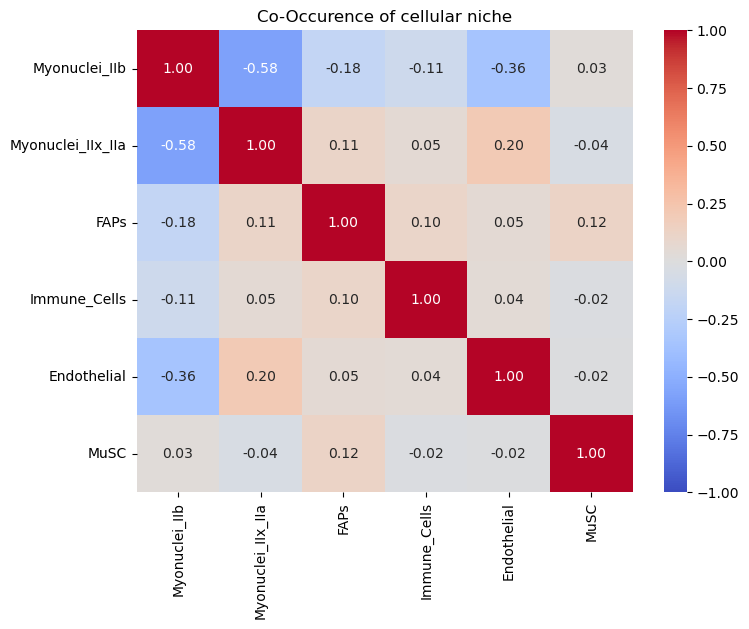

In [177]:
#Niche correlation graph
population_of_interest = ['Myonuclei_IIb', 'Myonuclei_IIx_IIa', 'FAPs', 'Immune_Cells', 'Endothelial', 'MuSC']
df_cachexia = weights_df[population_of_interest]

plt.figure(figsize=(8,6))
sns.heatmap(df_cachexia.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Co-Occurence of cellular niche")
plt.show